<div style="text-align: center;">

# Multi-Hazard Climate Screening: European Waste Facilities

</div>

This notebook shows how to run a client-facing multi-hazard screening workflow for a small waste-management portfolio. It combines portfolio setup, hazard scores, selected loss views, clustering, portfolio aggregation, and traceability tables in one end-to-end narrative.

The example portfolio contains three European facilities: a waste-to-energy plant, a materials recovery facility, and a transfer station. The purpose is not to model a real client portfolio exactly. The purpose is to show how a technical team can move from physical climate-risk evidence to practical business interpretation while keeping the assumptions visible.

The workflow is:

1. load configuration, credentials, and helper modules,
2. inspect the waste-facility portfolio,
3. review hazard scores across multiple hazards,
4. zoom in on selected material hazards and translate them into annual loss, tail-risk, or additional operating-cost views,
5. use clustering to identify assets that may be affected together by the same hazard,
6. aggregate the clustered risk results at portfolio level,
7. preserve provenance and methodological traceability.

**New to the Alpha-Klima API?** You may want to explore `01_hazard_data_api_basics.ipynb` and `02_asset_impact_api_basics.ipynb` first. Those notebooks introduce the raw hazard-data and asset-impact responses used here. This notebook assumes those API ideas are familiar enough that we can focus on portfolio interpretation.


## 1. Setup

When you run the notebook for the first time, select `.venv` as the interpreter. If you are unable to find the `.venv` interpreter, please follow the *Setup* instructions in the `README.md` to set it up.

### 1.1 Imports

The notebook uses a mix of standard Python packages and project-specific helpers:

* `json` loads the waste-facility portfolio input data.
* `os`, `sys`, `pathlib`, and `python-dotenv` handle configuration, paths, and API credentials.
* `time` supports retry delays for API requests.
* `numpy` and `pandas` handle numerical operations and tabular results.
* `plotly` creates the screening and financial visualizations.
* `requests` sends HTTPS requests to the Alpha-Klima API.
* `cooling_model`, `financial_metrics_plots`, `geometry_maps_plots`, `pipeline_client`, and `tail_metrics` provide reusable project-specific calculations, portfolio-pipeline access, and plots.
* `IPython.display` displays tables directly in the notebook.


In [1]:
import json
import os
import sys
import time
from collections import Counter
from pathlib import Path


NOTEBOOKS_ROOT = Path.cwd().parent
if str(NOTEBOOKS_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_ROOT))

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import requests
from auxiliary_functions import cooling_model as cm
from auxiliary_functions import financial_metrics_plots as fmp
from auxiliary_functions import geometry_maps_plots as gmp
from auxiliary_functions.pipeline_client import PhysicalAssetPipeline
from auxiliary_functions import tail_metrics as tm
from dotenv import load_dotenv
from IPython.display import display


In [2]:
# Ensure Plotly figures render both interactively and in static notebook viewers.
import plotly.io as pio

pio.renderers.default = "notebook+png"

### 1.2 Load API Configuration

The API base URL and API key are read from `../../.env`, which is two levels above this notebook. If you have not configured the `.env` file, please follow the *API Credentials* instructions in the `README.md` to set it up.

Expected environment variables:

- `ALPHA_KLIMA_API_KEY`: API key used to authenticate requests.
- `ALPHA_KLIMA_API_BASE_URL`: base URL of the Alpha-Klima API, without a trailing slash requirement.

In [3]:
load_dotenv("../../.env")
API_KEY = os.environ.get("ALPHA_KLIMA_API_KEY")
API_BASE = os.environ.get("ALPHA_KLIMA_API_BASE_URL", "").rstrip("/")
HEADERS = {"X-API-Key": API_KEY, "Accept": "application/json"}
assert API_KEY and API_BASE, "Set ALPHA_KLIMA_API_KEY and ALPHA_KLIMA_API_BASE_URL in ../../.env"

## 2. Configure the Exercise

### 2.1 Data

The exercise portfolio is loaded from `../../resources/waste_facilities.json`. That file contains a synthetic waste-management portfolio for Western Europe. The notebook reads the JSON, sends the facility locations and routing attributes to the Alpha-Klima API, and uses the exposure fields in side calculations such as flood-loss scaling, wind-loss scaling, and additional cooling cost.

The user can edit `waste_facilities.json` to modify this exercise. For example, you can change coordinates to test a different location, change structure or contents values to test financial sensitivity, adjust floor area for the cooling calculation, add or remove facilities, or replace the example portfolio with client data that follows the same structure.

The JSON has two main parts:

- `metadata`: explanatory information about the example dataset. It is useful context for users, but it is not used directly in the calculations.
- `items`: the asset records. Each object in `items` represents one waste-management facility.

For practical editing, the asset fields fall into four groups:

- **Required for the physical-risk calculation**: `id`, `name`, `country`, `latitude`, and `longitude`. The API uses the coordinates to look up hazard data at each facility location. The notebook also uses `id` to match API results back to the portfolio.
- **Required or important for the loss and exposure views in this notebook**: `structure_value`, `contents_value`, and `floor_area_m2`. `value` is the replacement value of the facility and is the sum of `structure_value` and `contents_value`. Contents here means the fixed process equipment and machinery rather than anything mobile. Both the flood and the wind view are priced against `value`. `floor_area_m2` is used to estimate additional cooling cost.
- **Optional fields that enrich model routing or interpretation**: `occupancy_code`, `asset_class`, `type`, `location`, `number_of_storeys`, `basement`, `first_floor_height`, and `hazus_wind_type`. The notebook reads these values from each JSON asset when they are available, and falls back to built-in defaults when a field is missing. In the example data, `occupancy_code = 1151` is the OED general industrial route that reaches the Hazus IND1 flood structure curve.
- **Optional descriptive and contextual fields**: `display_type`, `description`, `zone`, and `group`. These make the outputs easier to read and explain, but they do not drive the physical hazard lookup.

When replacing the example data, keep latitude and longitude in decimal degrees, keep `id` values unique, and review the economic assumptions in the configuration cell so that values such as electricity tariff and floor area match the replacement portfolio.

### 2.2 Inputs

The following cell defines the exercise inputs. This is the main place where the user typically makes changes before running the notebook, in case they want to modify the exercise. The inputs are grouped by how often they need to be changed:

- **Required inputs** identify the portfolio file used in this exercise. Without this, the notebook does not know which assets to send to the API.
- **Analysis options** control the hazards, climate scenarios, and years requested from Alpha-Klima. Changing these changes the physical risk evidence collected from the API.
- **Economic assumptions** translate physical impacts into business terms, for example electricity prices for cooling-cost estimates. These values should be reviewed against the user's own data before using the notebook for decision support.
- **Advanced settings** are useful for sensitivity testing or specialist analysis, including fallback model routing and VaR / Expected Shortfall percentiles. Most users can leave them unchanged on a first run.
- **Presentation settings** only affect labels, colors, and saved outputs; they do not change the analytical results.

Start by reviewing the required inputs. Then adjust the analysis scope and economic assumptions only where they differ from the portfolio or client use case being demonstrated.

In [4]:
REQUIRED_INPUTS = {
    # Portfolio file containing the waste facilities and their location/exposure attributes.
    "portfolio": "../../resources/waste_facilities.json",
}

ANALYSIS_OPTIONS = {
    # Flood scenarios and years requested from the API for riverine/coastal screening.
    "flood_scenarios": ["rcp8p5", "rcp4p5"],
    "flood_years": [2035, 2085],
    # Main flood slice used for detailed financial interpretation.
    "flood_headline_scenario": "rcp8p5",
    "flood_headline_year": 2085,
    # Wind slice used for expected-loss interpretation.
    "wind_scenario": "historical",
    "wind_year": 1999,
    # Chronic heat slice used for cooling-cost interpretation.
    "heat_scenario": "ssp585",
    "heat_year": 2050,
    "heat_hist_scenario": "historical",
    "heat_hist_year": 2005,
    "heat_base_c": 24.0,
    # Hazard indicators requested from Alpha-Klima. Keep this broad for first-pass screening.
    "score_scope": {
        "RiverineInundation": ["flood_depth"],
        "CoastalInundation": ["flood_depth"],
        "Wind": ["wind_speed/3s"],
        "Fire": ["fire_probability"],
        "Hail": ["hail_probability"],
        "Drought": ["cdd"],
        "WaterRisk": ["water_stress"],
        "Subsidence": ["subsidence_susceptability"],
        "Landslide": ["landslide_susceptability"],
        "ChronicHeat": ["cooling_degree_days/index"],
        "Snow": ["blizzard_probability"],
        "FreezingRain": ["freezing_rain_probability"],
    },
    "score_scenarios": ["historical", "rcp4p5", "rcp8p5", "ssp126", "ssp245", "ssp585"],
    "score_years": [2005, 2035, 2050, 2085],
}

ECONOMIC_ASSUMPTIONS = {
    # Non-household electricity tariff used to convert extra cooling demand into annual cost.
    # One reference tariff is applied to every site so costs stay comparable across countries.
    "electricity_tariff_eur_per_kwh": 0.155,
    "tariff_source": "Eurostat nrg_pc_205 (Spain, non-household band, incl. taxes and levies), applied to all sites as a single reference tariff",
}

ADVANCED_SETTINGS = {
    # Asset used for the detailed flood loss-tail example.
    "var_es_asset": "WM2",
    # Percentiles follow the helper convention: 95 means VaR 95%, not 0.95.
    "var_es_percentiles": [95, 99, 99.5],
    # Single-asset impact distributions have few bins, so interpolation gives a smoother quantile.
    "var_es_interpolate": True,
    # Used only when a generic RealEstate fallback route is required.
    "fallback_occupancy_code": -1,
}

PRESENTATION_SETTINGS = {
    "output_dir": "demo_outputs_waste_multihazard",
    "palette": {
        "teal": "#0092A0",
        "orange": "#E15E0B",
        "violet": "#4A3AA7",
        "ink": "#0b0b0b",
        "ink2": "#52514e",
        "muted": "#898781",
        "grid": "#e1e0d9",
        "axis": "#c3c2b7",
        "surface": "#fcfcfb",
    },
    "component_color": {"Building": "#0092A0", "Contents": "#4A3AA7"},
    "band_colors": ["#2f9e44", "#f59f00", "#e8590c", "#c92a2a"],
    "score_labels": {0: "No risk", 1: "Low", 2: "Medium", 3: "High"},
    "hazard_label": {
        "RiverineInundation": "Riverine flood",
        "CoastalInundation": "Coastal flood",
        "Wind": "Wind",
        "Fire": "Wildfire",
        "Hail": "Hail",
        "Drought": "Drought",
        "WaterRisk": "Water stress",
        "Subsidence": "Subsidence",
        "Landslide": "Landslide",
        "ChronicHeat": "Chronic heat",
        "Snow": "Snow",
        "FreezingRain": "Freezing rain",
    },
}

CONFIG = {**REQUIRED_INPUTS, **ANALYSIS_OPTIONS, **ECONOMIC_ASSUMPTIONS, **ADVANCED_SETTINGS}
PALETTE = PRESENTATION_SETTINGS["palette"]
COMPONENT_COLOR = PRESENTATION_SETTINGS["component_color"]
BAND_COLORS = PRESENTATION_SETTINGS["band_colors"]
SCORE_LABELS = PRESENTATION_SETTINGS["score_labels"]
HAZARD_LABEL = PRESENTATION_SETTINGS["hazard_label"]
OUT = Path(PRESENTATION_SETTINGS["output_dir"])
OUT.mkdir(exist_ok=True)

### 2.3 Helpers

The following cells define helper functions used throughout the notebook.

Most helpers do one small job: send an API request, extract a damage ratio, extract a risk score, read an impact distribution, or request cooling-degree-day values for a set of points. Keeping these helpers small makes the later analysis cells easier to read, especially for users who want to understand the workflow without becoming experts in the API response schema.

Everything else is computed by the API platform. The notebook does not contain local vulnerability curves. 

In [5]:
def api_post(path, payload, retries=5, timeout=240):
    "POST JSON to the API with retry/backoff on 5xx; raises on 4xx and returns the parsed body."
    last = None
    for attempt in range(retries):
        r = requests.post(API_BASE + path, json=payload, headers=HEADERS, timeout=timeout)
        if r.status_code < 500:
            r.raise_for_status()
            return r.json()
        last = r
        time.sleep(4 * (attempt + 1))
    last.raise_for_status()


def assess(items, scope, scenarios, years, calc_details=False, interpolate=True):
    "POST /api/get_asset_impact_clean for the given engine items and hazard scope."
    req = {"assets": {"items": items},
           "include_asset_level": True, "include_measures": True,
           "include_calc_details": calc_details, "clean_response": True,
           "years": years, "scenarios": scenarios,
           "calc_settings": {"hazard_scope_by_indicator": scope, "interpolate_years": interpolate}}
    return api_post("/api/get_asset_impact_clean", req)


def base_item(it):
    "Minimal engine asset (id, name, country, lat/lon) shared by every routing variant."
    return {"id": str(it["id"]), "asset_name": it["name"], "country": it.get("country", "ES"),
            "latitude": it["latitude"], "longitude": it["longitude"]}


def _no_year(year):
    "True if a response key carries no year, as the platform's historical records do."
    return year in (None, "None", "")


def _match(im, hazard, scenario, year):
    "True if an impact record is for the given hazard/scenario/year key."
    k = im["key"]
    if k["hazard_type"] != hazard or k["scenario_id"] != scenario:
        return False
    # Historical records come back with `year` unset, so a historical request matches the single
    # historical slice the platform returns rather than a year the caller would have to guess.
    if scenario == "historical" and _no_year(k.get("year")):
        return True
    return str(k.get("year")) == str(year)


def ratio_by_id(resp, hazard, scenario, year):
    "Map asset_id -> damage ratio (impact_mean) for one hazard/scenario/year, 0.0 when absent."
    out = {}
    for a in resp.get("asset_impacts", []):
        for im in a.get("impacts", []):
            if _match(im, hazard, scenario, year):
                out[a["asset_id"]] = im.get("impact_mean") or 0.0
    return out


def exceedance(resp, asset_id, hazard, scenario, year):
    "Loss-ratio exceedance curve (values, annual exceedance probabilities) for one asset."
    for a in resp.get("asset_impacts", []):
        if a["asset_id"] != str(asset_id):
            continue
        for im in a.get("impacts", []):
            if _match(im, hazard, scenario, year):
                ex = im.get("impact_exceedance") or {}
                return ex.get("values"), ex.get("exceed_probabilities")
    return None, None




def distribution(resp, asset_id, hazard, scenario, year):
    "Impact distribution (bin edges, bin probabilities) for one asset: the PMF behind the tail metrics."
    for a in resp.get("asset_impacts", []):
        if a["asset_id"] != str(asset_id):
            continue
        for im in a.get("impacts", []):
            if _match(im, hazard, scenario, year):
                d = im.get("impact_distribution") or {}
                return d.get("bin_edges"), d.get("probabilities")
    return None, None


def _measure_order(m):
    "Sort measures by horizon then scenario, so ties report the earliest scenario/year."
    key = m["key"]
    try:
        year = int(key.get("year"))
    except (TypeError, ValueError):
        year = 0
    return (year, str(key.get("scenario_id")))


def score_matrix(resp, items):
    "Worst 0-3 score per asset and hazard across the requested scenarios and horizons."
    # Returns (scores, drivers); `drivers` records the 'scenario / year' at which each worst score is
    # first reached, so every cell traces back to a specific scenario and horizon.
    # Records with no `hazard_indicator_id` are placeholders the platform emits for every hazard it
    # supports, including hazards it holds no vulnerability model for on this asset type. They carry
    # a negative sentinel instead of a 0-3 band (-1 no vulnerability model for the asset type,
    # -2 no data, -3 error), so they are skipped here: a hazard earns a column only where some
    # scenario and horizon produced a real score.
    ids = [str(it["id"]) for it in items]
    n = len(ids)
    best, driver = {}, {}
    for m in sorted(resp.get("risk_measures", {}).get("measures_for_assets", []), key=_measure_order):
        key = m["key"]
        if key.get("hazard_indicator_id") is None:
            continue
        hz = key["hazard_type"]
        year = key.get("year")
        tag = str(key.get("scenario_id")) if _no_year(year) else f'{key.get("scenario_id")} / {year}'
        sc = m.get("scores") or []
        b = best.setdefault(hz, [np.nan] * n)
        d = driver.setdefault(hz, [""] * n)
        for i in range(min(n, len(sc))):
            if sc[i] is None or int(sc[i]) < 0:
                continue
            v = int(sc[i])
            if np.isnan(b[i]) or v > b[i]:
                b[i], d[i] = v, tag
    scores, drivers = pd.DataFrame({"id": ids}), pd.DataFrame({"id": ids})
    for hz in best:
        if all(np.isnan(v) for v in best[hz]):
            continue                       # requested, but no scenario or horizon returned a score
        scores[hz], drivers[hz] = best[hz], driver[hz]
    return scores, drivers


def cdd_at(curve, base):
    "Cooling-degree-day value from an intensity curve at the base temperature closest to `base`."
    idx = curve.get("index_values") or []
    val = curve.get("intensities") or []
    if not idx:
        return np.nan
    j = int(np.argmin(np.abs(np.asarray(idx, float) - base)))
    return float(val[j]) if j < len(val) else np.nan


def heat_cdd_at_points(lats, lons, scenario, year, base):
    "CDD at each point for one scenario/year via /api/get_hazard_data (cooling_degree_days/index)."
    resp = api_post("/api/get_hazard_data", {"items": [{
        "request_item_id": "heat", "event_type": "ChronicHeat",
        "indicator_id": "cooling_degree_days/index", "scenario": scenario, "year": year,
        "latitudes": list(lats), "longitudes": list(lons)}]})
    return [cdd_at(c, base) for c in resp["items"][0]["intensity_curve_set"]]

In [6]:
def style_plot(fig, title, subtitle="", height=460):
    "Apply the shared demo theme (palette, fonts, layout) and title/subtitle to a Plotly figure."
    t = "<b>" + title + "</b>"
    if subtitle:
        t += "<br><span style='font-size:12px;color:" + PALETTE["ink2"] + "'>" + subtitle + "</span>"
    fig.update_layout(
        title=dict(text=t, font=dict(size=18, color=PALETTE["ink"])),
        font=dict(family="system-ui, -apple-system, Segoe UI, sans-serif", size=13, color=PALETTE["ink2"]),
        paper_bgcolor=PALETTE["surface"], plot_bgcolor=PALETTE["surface"], height=height,
        margin=dict(t=78, b=54, l=68, r=28),
        legend=dict(orientation="h", yanchor="bottom", y=-0.24, x=0, font=dict(color=PALETTE["ink2"])))
    fig.update_xaxes(gridcolor=PALETTE["grid"], zeroline=False, linecolor=PALETTE["axis"],
                     tickfont=dict(color=PALETTE["muted"]), title_font=dict(color=PALETTE["ink2"]))
    fig.update_yaxes(gridcolor=PALETTE["grid"], zeroline=False, linecolor=PALETTE["axis"],
                     tickfont=dict(color=PALETTE["muted"]), title_font=dict(color=PALETTE["ink2"]))
    return fig


def save_plot(fig, name):
    "Write the figure to demo_outputs as standalone HTML (CDN Plotly) and return it."
    fig.write_html(OUT / (name + ".html"), include_plotlyjs="cdn")
    return fig


def save_table(df, name):
    "Write the DataFrame to demo_outputs as CSV and return it."
    df.to_csv(OUT / (name + ".csv"), index=False)
    return df

## 3. Portfolio Overview

Start by understanding the facilities under analysis before looking at risk outputs. The figures in this section provide the factual base for the rest of the notebook.

The example portfolio contains three waste-management sites with deliberately different risk profiles:

- a waste-to-energy plant near the Waal river in Nijmegen;
- a materials recovery facility in the Garonne estuary area near Bordeaux;
- a waste transfer station on the Venetian mainland.

Each facility carries a structure value, a process-contents value, a floor area, and industrial routing attributes. These values are illustrative. They are included so the notebook can demonstrate how physical risk evidence becomes portfolio-level financial interpretation.

In [7]:
items = json.load(open(CONFIG["portfolio"], encoding="utf-8"))["items"]
overview = pd.DataFrame([{"id": it["id"], "name": it["name"], "type": it.get("display_type", it.get("type", "Facility")),
                          "country": it.get("country", ""), "structure_value_M": round(it["structure_value"] / 1e6, 1),
                          "contents_value_M": round(it.get("contents_value", 0) / 1e6, 1),
     "value_M": round(it["value"] / 1e6, 1),
                          "wind_type": it.get("hazus_wind_type", "")} for it in items])
save_table(overview, "t_portfolio")
tot = sum(it["value"] for it in items)  # value already covers contents
print(len(items), "facilities | total exposed value EUR", round(tot / 1e6, 1), "M")
display(overview)

3 facilities | total exposed value EUR 131.0 M


,id,name,type,country,structure_value_M,contents_value_M,value_M,wind_type
0,WM1,Afval Energie Centrale Nijmegen,Waste-to-energy plant,NL,45.0,30.0,75.0,MLRI
1,WM2,Centre de tri Bordeaux,Materials recovery facility (MRF),FR,26.0,14.0,40.0,SPMBM
2,WM3,Stazione di trasferimento Venezia,Waste transfer station,IT,12.0,4.0,16.0,SPMBM


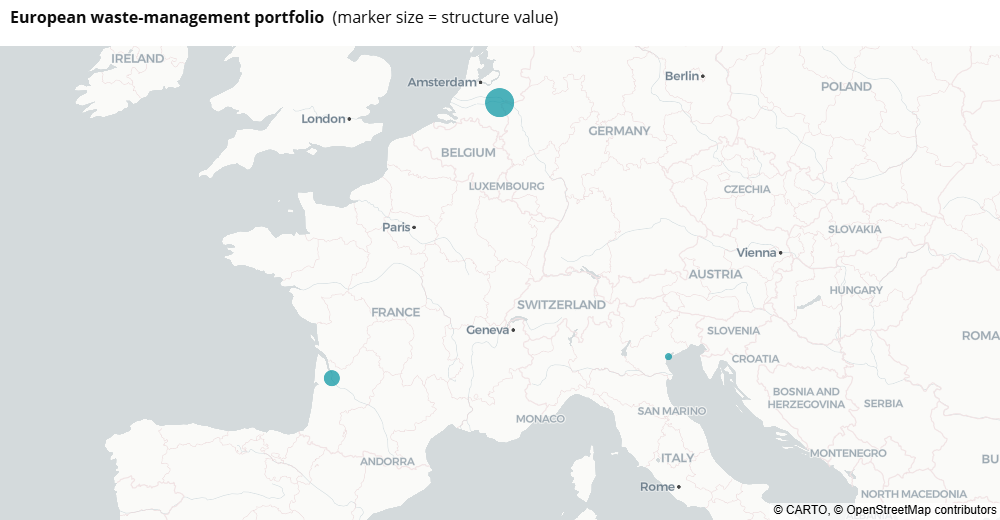

In [8]:
fig = gmp.show_portfolio(
    latitudes=[it["latitude"] for it in items], longitudes=[it["longitude"] for it in items],
    asset_ids=[it["id"] for it in items], names=[it["name"] for it in items],
    values=[it["value"] for it in items])
zoom_customized = 4.2
fig.update_layout(map=dict(zoom=zoom_customized), height=520, margin=dict(l=0, r=0, t=46, b=0),
                  title=dict(text="<b>European waste-management portfolio</b>  (marker size = structure value)",
                             font=dict(size=16, color=PALETTE["ink"]), x=0.01))
save_plot(fig, "p_portfolio_map")
fig.show()

## 4. Portfolio Risk Score Table

This section is the first portfolio triage layer. It asks a simple screening question before moving into detailed loss calculations: **which hazards appear most relevant for each waste facility, and under which scenario and year do they become most severe?**

The notebook sends the facilities to the Alpha-Klima API and requests risk scores across the hazards, scenarios, and years defined in the configuration of the _2.2 Inputs_ section. The API response includes risk as a 0-to-3 score:

- `0`: no material risk signal in the requested scope;
- `1`: low risk;
- `2`: medium risk;
- `3`: high risk.

For each asset and hazard, the table reports the **worst score reached across all requested scenarios and horizons**. This means the score is intentionally conservative for screening: if flood is low in 2035 but high in 2085, the flood column shows the high score so the hazard is not missed.

These scores are useful for prioritization, but they are **not the same as financial loss**. A high score means the facility has a strong hazard or impact signal in the requested scenario set; it does not by itself say how many euros are at risk. The later sections translate selected material hazards into financial views.

In [9]:
def score_item_native(it):
    "Asset under the native waste occupancy routing (occ 1151 -> Hazus IND in this example)."
    item = base_item(it)
    item.update({"occupancy_code": it.get("occupancy_code", 1151),
                 "location": it.get("location", "Europe")})
    return item


def score_item_generic(it):
    "Same asset under the generic RealEstate fallback for hazards the native route does not resolve."
    item = base_item(it)
    item.update({"occupancy_code": CONFIG["fallback_occupancy_code"],
                 "asset_class": it.get("asset_class", "RealEstateAsset"),
                 "type": it.get("type", "Generic"),
                 "country": it.get("country", "ES"),
                 "location": it.get("location", "Europe")})
    return item


# Two routings: the industrial occupancy binds flood, wildfire and landslide in this workflow; the rest
# resolve through a generic RealEstate routing. Prefer the specific occupancy score where present.
sm_native, dv_native = score_matrix(assess([score_item_native(it) for it in items], CONFIG["score_scope"],
                                           CONFIG["score_scenarios"], CONFIG["score_years"]), items)
sm_generic, dv_generic = score_matrix(assess([score_item_generic(it) for it in items], CONFIG["score_scope"],
                                             CONFIG["score_scenarios"], CONFIG["score_years"]), items)
ids, names = [str(it["id"]) for it in items], [it["name"] for it in items]
scores = pd.DataFrame({"id": ids, "name": names})
drivers = pd.DataFrame({"id": ids, "name": names})
for hz in CONFIG["score_scope"]:
    nat = sm_native[hz] if hz in sm_native.columns else None
    gen = sm_generic[hz] if hz in sm_generic.columns else None
    if nat is None and gen is None:
        continue                           # neither routing scored this hazard
    if gen is None:
        scores[hz], drivers[hz] = nat, dv_native[hz]
    elif nat is None:
        scores[hz], drivers[hz] = gen, dv_generic[hz]
    else:
        # Cell by cell, so a hazard the occupancy routing scores for one facility but not another
        # still falls back to the generic routing for the remaining facilities.
        keep = nat.notna()
        scores[hz] = nat.where(keep, gen)
        drivers[hz] = dv_native[hz].where(keep, dv_generic[hz])

haz_cols = [h for h in CONFIG["score_scope"] if h in scores.columns]
scores["worst_score"] = scores[haz_cols].max(axis=1)
scores["worst_hazard"] = scores[haz_cols].idxmax(axis=1)
scores["worst_scenario_horizon"] = [drivers.loc[i, hz] for i, hz in scores["worst_hazard"].items()]
save_table(scores, "t_risk_scores")
_ = save_table(drivers, "t_risk_score_drivers")

print("Scenarios scanned:", ", ".join(CONFIG["score_scenarios"]))
print("Horizons scanned :", ", ".join(str(y) for y in CONFIG["score_years"]))

Scenarios scanned: historical, rcp4p5, rcp8p5, ssp126, ssp245, ssp585
Horizons scanned : 2005, 2035, 2050, 2085


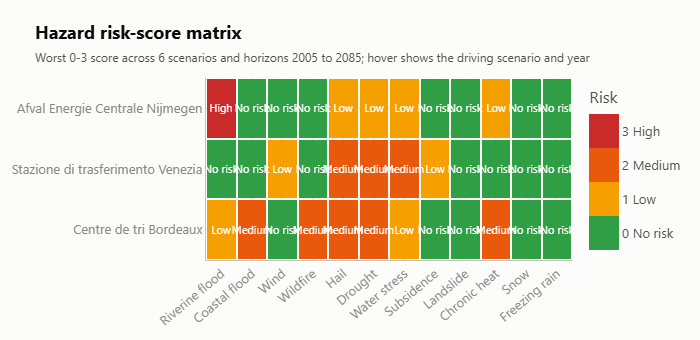

In [10]:
haz_cols = [h for h in CONFIG["score_scope"] if h in scores.columns]
order = scores.sort_values("worst_score", ascending=True)
z = order[haz_cols].to_numpy(dtype=float)
cd = drivers.set_index("id").loc[order["id"], haz_cols].to_numpy()   # driving scenario / year per cell
n = len(BAND_COLORS)
colorscale = []
for i, c in enumerate(BAND_COLORS):
    colorscale += [[i / n, c], [(i + 1) / n, c]]
fig = go.Figure(go.Heatmap(
    z=z, x=[HAZARD_LABEL[h] for h in haz_cols], y=order["name"], customdata=cd,
    text=[[SCORE_LABELS.get(int(v), "") if v == v else "" for v in row] for row in z],
    texttemplate="%{text}", textfont=dict(size=11, color="white"),
    colorscale=colorscale, zmin=-0.5, zmax=3.5,
    colorbar=dict(title="Risk", tickvals=[0, 1, 2, 3], ticktext=["0 No risk", "1 Low", "2 Medium", "3 High"]),
    hovertemplate="%{y}<br>%{x}: score %{z}<br>first reached at %{customdata}<extra></extra>", xgap=2, ygap=2))
style_plot(fig, "Hazard risk-score matrix",
           f"Worst 0-3 score across {len(CONFIG['score_scenarios'])} scenarios and horizons "
           f"{min(CONFIG['score_years'])} to {max(CONFIG['score_years'])}; "
           f"hover shows the driving scenario and year", height=340)
fig.update_xaxes(tickangle=-40)
save_plot(fig, "p_score_matrix")
fig.show()

Each score above is the **worst** band reached over those scenarios and horizons. The table hover shows *where* each one occurs, as `scenario / year`, so every cell traces back to a specific scenario and horizon. Where a hazard reaches the same worst band under several scenarios or horizons, the **earliest** one is reported: `historical / 2005` therefore means the hazard is already at that band today, not only under a future scenario.

**Reading the table.** The 0-to-3 scores are all shown in the same format, but they are not all calculated in the same way.

For some hazards, Alpha-Klima can apply a **damage or impact model** for the asset type. In those cases, the score reflects both the hazard intensity and how vulnerable the waste facility is expected to be. In this notebook, that applies to riverine and coastal flood, wind, wildfire, landslide, and chronic heat.

For other hazards, the score is a **hazard screening signal**. The API evaluates the hazard indicator itself against fixed thresholds, without applying a facility-specific damage curve. In this notebook, that applies to water stress, subsidence, drought, hail, snow, and freezing rain.

The waste facilities are first sent under their industrial routing, using the routing fields from `waste_facilities.json`. The notebook also sends a generic real-estate fallback request for hazards that the industrial route does not resolve. Where both routes return a score, the industrial route is preferred.

This distinction matters because a score tells us where to focus, but not always how to price the risk. The next sections price the hazards that are most material and interpretable for this portfolio: **flood**, **wind**, and **chronic heat**. The traceability section at the end records the method used for every hazard.

## 5. Flood Loss View per Asset

The score table showed that flood is one of the material hazards for this waste-facility portfolio. This section therefore moves from a **screening score** to a **financial loss view** for the headline flood case configured in the _2.2 Inputs_ section.

The notebook requests both riverine and coastal inundation using the `flood_depth` indicator. For each facility, it reads the expected damage ratio returned by the API and keeps whichever flood type is larger for the configured headline scenario and year. This is a pragmatic screening choice: it shows the dominant flood driver for each site without hiding whether the driver is riverine or coastal.

The value base is `value` from `waste_facilities.json`, which is `structure_value` plus `contents_value`: the building or plant together with its fixed process equipment. The platform returns an expected damage ratio, `impact_mean`, from the Hazus industrial structure curve reached through the facility's industrial occupancy routing. The notebook converts that ratio into euros by multiplying it by that value:

- expected building loss = `value x flood damage ratio`.

**How the damage curve is composed:** the platform resolves the industrial occupancy to a single combined _Hazus IND1_ curve that already covers structure, components and inventory damage, so it returns one damage ratio per asset rather than a per-component breakdown. Selecting an individual damage component is a planned platform feature. The notebook applies that combined ratio to `value`, which is `structure_value` plus `contents_value`, so the value base covers the same things as the curve. The wind view later uses the same `value`.

Read the results as annual expected loss estimates for screening and comparison. They are useful for ranking facilities and understanding order of magnitude, but they are not a full engineering loss study or regulatory capital calculation.


In [11]:
FLOOD_SCOPE = {"RiverineInundation": ["flood_depth"], "CoastalInundation": ["flood_depth"]}
FSC, FYR = CONFIG["flood_headline_scenario"], CONFIG["flood_headline_year"]


def flood_item(it):
    "Structure asset for flood pricing: asset occupancy route with Hazus flood defaults as fallbacks."
    item = base_item(it)
    item.update({"occupancy_code": it.get("occupancy_code", 1151),
                 "location": it.get("location", "Europe"),
                 "number_of_storeys": it.get("number_of_storeys", -1),
                 "basement": it.get("basement", 0),
                 "first_floor_height": it.get("first_floor_height", 0.305)})
    return item


flood = assess([flood_item(it) for it in items], FLOOD_SCOPE, CONFIG["flood_scenarios"], CONFIG["flood_years"])
riv = ratio_by_id(flood, "RiverineInundation", FSC, FYR)
coa = ratio_by_id(flood, "CoastalInundation", FSC, FYR)

rows = []
for it in items:
    rid = str(it["id"])
    r_riv, r_coa = riv.get(rid, 0.0), coa.get(rid, 0.0)
    hz = "CoastalInundation" if r_coa > r_riv else "RiverineInundation"
    struct_ratio = max(r_riv, r_coa)
    rows.append({"id": rid, "name": it["name"], "driver": hz.replace("Inundation", ""),
                 "building_value": it["value"], "struct_ratio": struct_ratio,
                 "expected_building_loss": it["value"] * struct_ratio})
flood_df = pd.DataFrame(rows)
flood_df["expected_total_flood_loss"] = flood_df["expected_building_loss"]
save_table(flood_df, "t_flood_loss")
print("Total expected flood structure loss EUR", round(flood_df["expected_total_flood_loss"].sum() / 1e6, 2), "M/yr (", FSC, FYR, ")")
display(flood_df[["name", "driver", "struct_ratio", "expected_building_loss"]])

Total expected flood structure loss EUR 5.91 M/yr ( rcp8p5 2085 )


,name,driver,struct_ratio,expected_building_loss
0,Afval Energie Centrale Nijmegen,Riverine,0.06494,4870500.0
1,Centre de tri Bordeaux,Coastal,0.02591,1036400.0
2,Stazione di trasferimento Venezia,Riverine,0.00000,0.0


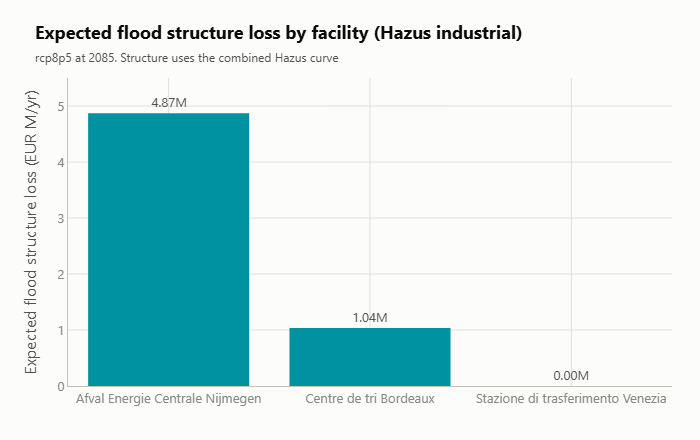

In [12]:
comp = flood_df.sort_values("expected_building_loss", ascending=False)
fig = go.Figure(go.Bar(x=comp["name"], y=comp["expected_building_loss"] / 1e6, marker_color=PALETTE["teal"],
                       marker_line_width=0, text=[f"{v/1e6:,.2f}M" for v in comp["expected_building_loss"]],
                       textposition="outside", textfont=dict(color=PALETTE["ink2"]),
                       hovertemplate="%{x}: %{y:,.2f}M EUR/yr<extra></extra>"))
fig.update_yaxes(title="Expected flood structure loss (EUR M/yr)")
style_plot(fig, "Expected flood structure loss by facility (Hazus industrial)",
           f"{FSC} at {FYR}. Structure uses the combined Hazus curve", height=440)
save_plot(fig, "p_flood_structure")
fig.show()

### Flood Tail Risk: Value-at-Risk and Expected Shortfall

Expected annual loss is useful, but it only describes the average. For flood risk, the average can hide severe but less frequent outcomes. This section therefore looks at the **tail** of the flood loss distribution for the selected facility.

Two tail-risk metrics are shown:

- **Value-at-Risk (VaR)**: the loss level associated with a chosen confidence level. For example, VaR 99% is the 1-in-100 annual loss level: in the modelled distribution, losses exceed that value with about 1% annual probability.
- **Expected Shortfall (ES)**: the average loss in the same worst tail. For example, ES 99% is the average loss conditional on being in the worst 1% of outcomes. Because ES averages losses beyond the VaR threshold, it is always equal to or larger than VaR.

This asset-level tail view does not call Alpha-Klima's full production financial engine for portfolio VaR/ES. Instead, it calculates these metrics client-side from the `impact_distribution` already returned by the asset-impact API.

The calculation is implemented in `auxiliary_functions/tail_metrics.py`. This is a temporary client-side helper intended to mirror the Alpha-Klima financial methodology until the equivalent platform API endpoint is available. Percentiles use the 0-to-100 convention: use `99`, not `0.99`, for VaR 99%.

`CONFIG["var_es_interpolate"]` controls how quantiles are read from the binned `impact_distribution`. When interpolation is enabled, the notebook reads the quantile from a piecewise-linear cumulative distribution. This is smoother for single-asset examples where the API returns only a small number of bins. If interpolation is disabled, the result snaps to the discrete bin values instead.

The table below reports the selected facility's flood structure tail risk. The charts then compare structure VaR and Expected Shortfall across percentiles and climate scenarios.


In [13]:
VE_ID = CONFIG["var_es_asset"]
PCTS = CONFIG["var_es_percentiles"]
INTERP = CONFIG["var_es_interpolate"]
ve = next(it for it in items if str(it["id"]) == VE_ID)
HZV = "CoastalInundation" if flood_df.loc[flood_df["id"] == VE_ID, "driver"].iat[0] == "Coastal" else "RiverineInundation"


def structure_var_es(scenario, year):
    "Flood-structure VaR/ES for one scenario/year, as {percentile: (VaR, ES)}."
    be, bp = distribution(flood, VE_ID, HZV, scenario, year)
    return tm.var_es(be, bp, PCTS, scale=ve["value"], interpolate=INTERP)


ve_headline = structure_var_es(CONFIG["flood_headline_scenario"], CONFIG["flood_headline_year"])
var_es_df = pd.DataFrame([{"confidence": f"{p / 100:.1%}", "return_period": f"1-in-{round(1 / (1 - p / 100))}",
                           "VaR_building_k": round(ve_headline[p][0] / 1e3),
                           "ES_structure_k": round(ve_headline[p][1] / 1e3)} for p in PCTS])
save_table(var_es_df, "t_var_es")
print(ve["name"], "| 1-in-100 flood structure VaR EUR",
      var_es_df.loc[var_es_df["return_period"] == "1-in-100", "VaR_building_k"].iat[0],
      "k | ES EUR", var_es_df.loc[var_es_df["return_period"] == "1-in-100", "ES_structure_k"].iat[0], "k")
display(var_es_df)

Centre de tri Bordeaux | 1-in-100 flood structure VaR EUR 13084 k | ES EUR 14514 k


,confidence,return_period,VaR_building_k,ES_structure_k
0,95.0%,1-in-20,9929,11866
1,99.0%,1-in-100,13084,14514
2,99.5%,1-in-200,14275,15348


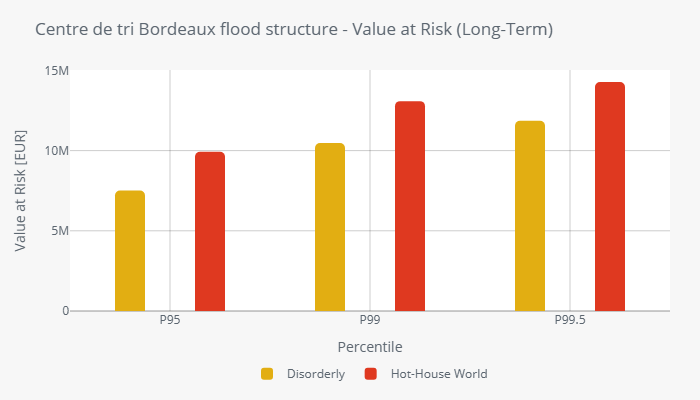

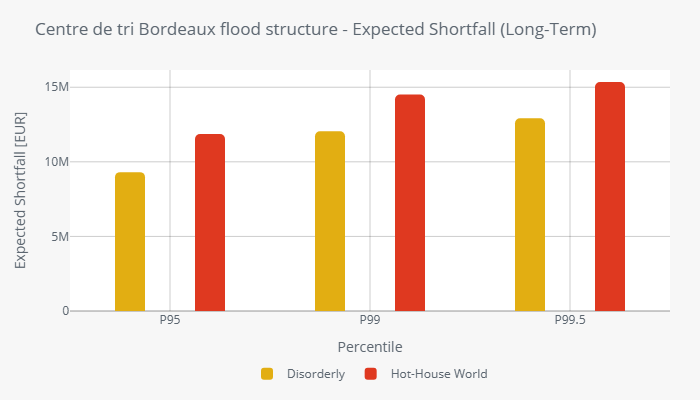

In [14]:
# Flood-structure VaR and ES per scenario and percentile, plotted with the shared helpers.
FYR_ = CONFIG["flood_headline_year"]
by_scenario = {s: structure_var_es(s, FYR_) for s in CONFIG["flood_scenarios"]}

# One payload carries both metrics; each plotter selects its own rows by label.
resp = tm.metrics_response(by_scenario, term="long")
fig = fmp.plot_var(resp, name=ve["name"] + " flood structure")
save_plot(fig, "p_var")
fig.show()
fig = fmp.plot_es(resp, name=ve["name"] + " flood structure")
save_plot(fig, "p_es")
fig.show()

## 6. Wind Loss View per Asset

Wind is another material hazard that can be expressed in euros, but it is priced differently from flood. Flood uses a combined industrial curve. European wind, in this workflow, uses the WISC extreme 3-second gust field (`wind_speed/3s`) and resolves through a generic building wind curve.

The reason is model routing. The Hazus industrial wind curves that provide a more specific industrial building view are keyed to the tropical-cyclone `max_speed` indicator. That indicator is effectively zero for these European sites, so the notebook requests WISC 3-second gust instead and sends the facilities under a generic real-estate routing for this view.

For each facility, the platform returns one aggregate wind damage ratio. The notebook applies that ratio to total insured value:

- expected wind loss = `value x wind damage ratio`.

There is no platform-provided structure/contents split for this European wind route. Interpret expected wind loss as an annual average loss under the selected wind field and value base. For this portfolio the ratios are small, so wind is mainly useful as a completeness check and as a comparison against flood.


In [15]:
WIND_SCOPE = {"Wind": ["wind_speed/3s"]}
WSC, WYR = CONFIG["wind_scenario"], CONFIG["wind_year"]


def wind_item(it):
    "Building asset for wind pricing: generic RealEstate curve for the WISC wind_speed/3s indicator."
    item = base_item(it)
    item.update({"occupancy_code": CONFIG["fallback_occupancy_code"],
                 "asset_class": it.get("asset_class", "RealEstateAsset"),
                 "type": it.get("type", "Generic"),
                 "country": it.get("country", "ES"),
                 "location": it.get("location", "Europe")})
    return item


wind = assess([wind_item(it) for it in items], WIND_SCOPE, [WSC], [WYR])
wind_ratio = ratio_by_id(wind, "Wind", WSC, WYR)

wind_df = pd.DataFrame([{
    "id": str(it["id"]), "name": it["name"],
    "insured_value": it["value"],  # already structure + contents
    "wind_ratio": wind_ratio.get(str(it["id"]), 0.0),
    "expected_wind_loss": it["value"] * wind_ratio.get(str(it["id"]), 0.0)}
    for it in items])
save_table(wind_df, "t_expected_wind_loss")
print("Total expected wind loss EUR", round(wind_df["expected_wind_loss"].sum() / 1e3, 1), "k/yr (", WSC, WYR, ")")
display(wind_df)

Total expected wind loss EUR 6.5 k/yr ( historical 1999 )


,id,name,insured_value,wind_ratio,expected_wind_loss
0,WM1,Afval Energie Centrale Nijmegen,75000000,0.000000,0.0
1,WM2,Centre de tri Bordeaux,40000000,0.000000,0.0
2,WM3,Stazione di trasferimento Venezia,16000000,0.000409,6542.4


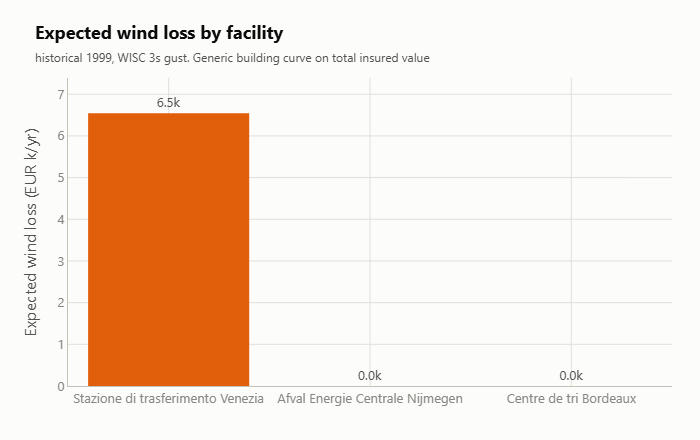

In [16]:
comp = wind_df.sort_values("expected_wind_loss", ascending=False)
fig = go.Figure(go.Bar(x=comp["name"], y=comp["expected_wind_loss"] / 1e3, marker_color=PALETTE["orange"],
                       marker_line_width=0, text=[f"{v/1e3:,.1f}k" for v in comp["expected_wind_loss"]],
                       textposition="outside", textfont=dict(color=PALETTE["ink2"]),
                       hovertemplate="%{x}: %{y:,.1f}k EUR/yr<extra></extra>"))
fig.update_yaxes(title="Expected wind loss (EUR k/yr)")
style_plot(fig, "Expected wind loss by facility",
           f"{WSC} {WYR}, WISC 3s gust. Generic building curve on total insured value", height=440)
save_plot(fig, "p_expected_wind_loss")
fig.show()

## 7. Chronic Heat View per Asset

Chronic heat is a **chronic hazard**. Unlike acute risks, which result in single damaging episodes, chronic heat builds up gradually through warmer conditions over time. In this notebook, it is therefore interpreted as an **additional operating cost** rather than as a one-off damage event.

The physical indicator used here is **cooling degree days**. Cooling degree days measure how much, and for how long, outdoor temperature is above a chosen cooling threshold. In this notebook the threshold is `heat_base_c`, set to 24 degrees C in the configuration of the _2.2 Inputs_ section. Higher cooling degree days indicate more demand for cooling, ventilation, or temperature-sensitive process control.

The notebook requests cooling-degree-day values from the Alpha-Klima hazard data API at each facility location for two cases:

- a historical baseline, configured as `heat_hist_scenario` and `heat_hist_year`;
- a future climate case, configured as `heat_scenario` and `heat_year`.

The result shown below is **not the total cooling bill**. It is the estimated additional cooling cost caused by warming: future cooling demand minus the historical baseline. This makes the output easier to interpret as climate-driven incremental cost rather than normal operating expenditure.

To convert additional cooling demand into euros, the notebook uses the helper in `auxiliary_functions/cooling_model.py`. The calculation scales cooling demand by `floor_area_m2`, applies simple cooling-system assumptions, and then prices the electricity demand using `electricity_tariff_eur_per_kwh`.

This is a transparent client-side interpretation layer built from API hazard data and configurable economic assumptions. The 0-to-3 chronic-heat score in the earlier screening table still comes from the platform score response, while the euro cost below is calculated in the notebook. Therefore the score and cost are related, but they are not the same metric and should not be expected to move one-for-one.


In [17]:
HEAT_SC, HEAT_YR = CONFIG["heat_scenario"], CONFIG["heat_year"]
lats = [it["latitude"] for it in items]; lons = [it["longitude"] for it in items]
cdd_now = heat_cdd_at_points(lats, lons, HEAT_SC, HEAT_YR, CONFIG["heat_base_c"])
cdd_hist = heat_cdd_at_points(lats, lons, CONFIG["heat_hist_scenario"], CONFIG["heat_hist_year"], CONFIG["heat_base_c"])
rows = []
for it, h, c in zip(items, cdd_hist, cdd_now):
    area = it.get("floor_area_m2", 0)
    rows.append({"id": str(it["id"]), "name": it["name"], "floor_area_m2": area,
                 "cdd_hist": h, "cdd_2050": c,
                 "excess_cooling_cost_eur": cm.excess_cooling_cost_eur(
                     c, h, area, tariff_eur_per_kwh=CONFIG["electricity_tariff_eur_per_kwh"])})
heat_df = pd.DataFrame(rows)
save_table(heat_df, "t_heat")
print("Total additional cooling cost vs baseline EUR",
      round(heat_df["excess_cooling_cost_eur"].sum() / 1e3, 1), "k/yr",
      "| mean CDD change:", round(np.nanmean((heat_df["cdd_2050"] - heat_df["cdd_hist"]).clip(lower=0))))
display(heat_df)

Total additional cooling cost vs baseline EUR 2.1 k/yr | mean CDD change: 42


,id,name,floor_area_m2,cdd_hist,cdd_2050,excess_cooling_cost_eur
0,WM1,Afval Energie Centrale Nijmegen,15000,3.586,22.72,533.8386
1,WM2,Centre de tri Bordeaux,8000,30.470,138.00,1600.0464
2,WM3,Stazione di trasferimento Venezia,4000,0.000,0.00,0.0000


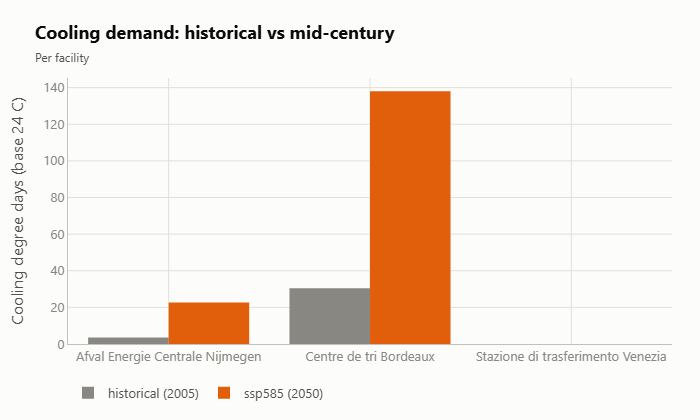

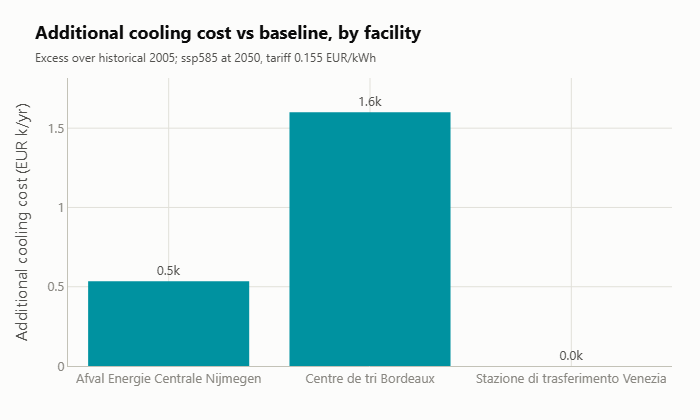

In [18]:
fig = go.Figure()
fig.add_trace(go.Bar(x=heat_df["name"], y=heat_df["cdd_hist"], name=f"{CONFIG['heat_hist_scenario']} ({CONFIG['heat_hist_year']})",
                     marker_color=PALETTE["muted"], marker_line_width=0,
                     hovertemplate="%{x} baseline: %{y:,.0f} CDD<extra></extra>"))
fig.add_trace(go.Bar(x=heat_df["name"], y=heat_df["cdd_2050"], name=f"{HEAT_SC} ({HEAT_YR})",
                     marker_color=PALETTE["orange"], marker_line_width=0,
                     hovertemplate="%{x} " + str(HEAT_YR) + ": %{y:,.0f} CDD<extra></extra>"))
fig.update_layout(barmode="group")
fig.update_yaxes(title=f"Cooling degree days (base {CONFIG['heat_base_c']:g} C)")
style_plot(fig, "Cooling demand: historical vs mid-century", "Per facility", height=420)
save_plot(fig, "p_cdd_change")
fig.show()

fig2 = go.Figure(go.Bar(x=heat_df["name"], y=heat_df["excess_cooling_cost_eur"] / 1e3, marker_color=PALETTE["teal"],
                        marker_line_width=0, text=[f"{v/1e3:,.1f}k" for v in heat_df["excess_cooling_cost_eur"]],
                        textposition="outside", textfont=dict(color=PALETTE["ink2"]),
                        hovertemplate="%{x}: %{y:,.1f}k EUR/yr<extra></extra>"))
fig2.update_yaxes(title="Additional cooling cost (EUR k/yr)")
style_plot(fig2, "Additional cooling cost vs baseline, by facility",
           f"Excess over {CONFIG['heat_hist_scenario']} {CONFIG['heat_hist_year']}; {HEAT_SC} at {HEAT_YR}, tariff "
           f"{CONFIG['electricity_tariff_eur_per_kwh']} EUR/kWh", height=420)
save_plot(fig2, "p_cooling_cost")
fig2.show()

## 8. Clustering

The asset-level sections above show how individual waste facilities respond to flood, wind, and chronic heat. Clustering is the next portfolio-analysis step for acute hazards: it identifies groups of assets that can be affected by the same hazard event and therefore should not be treated as fully independent in portfolio risk aggregation.

The API clustering workflow is hazard-agnostic. It runs after the portfolio risk pipeline and returns cluster definitions plus asset-to-cluster links for the hazards where clustering is relevant and available. In this waste-facility example, the code prioritizes the acute hazards priced earlier in the notebook, while still displaying any additional clustered hazards returned by the API.

> Warning: the portfolio risk and clustering runs may take a few minutes.

Each acute hazard uses its own spatial method, so both the cluster layout and the form of the cluster identifiers depend on the hazard being clustered. The clustering methods are described in the platform documentation.


In [19]:
def cluster_portfolio_item(it):
    "Physical-asset portfolio record for clustering the waste facilities."
    return {
        "id": str(it["id"]),
        "name": it["name"],
        "latitude": it["latitude"],
        "longitude": it["longitude"],
        "country": it.get("country", "ES"),
        "location": it.get("location", "Europe"),
        "occupancy_code": it.get("occupancy_code", 1151),
        "number_of_storeys": it.get("number_of_storeys", -1),
        "basement": it.get("basement", 0),
        "first_floor_height": it.get("first_floor_height", 0.305),
        "value": it["value"],
    }


waste_cluster_portfolio = {
    "portfolio": {"assets": [cluster_portfolio_item(it) for it in items]},
    "portfolio_name": "waste_facilities_clustering_demo",
}

pipeline = PhysicalAssetPipeline(
    api_base=API_BASE,
    api_key=API_KEY,
    portfolio=waste_cluster_portfolio,
)
portfolio_code = pipeline.portfolio_code

_ = pipeline.run_risk_analysis(
    requested_results=[f"api/physical-asset-portfolios/{portfolio_code}/assets/risks"]
)
clustering_results = pipeline.run_clustering(requested_results=[
    f"api/physical-asset-portfolios/{portfolio_code}/clusters",
    f"api/physical-asset-portfolios/{portfolio_code}/clusters/assets",
])
clusters = clustering_results[f"api/physical-asset-portfolios/{portfolio_code}/clusters"]
asset2cluster = clustering_results[f"api/physical-asset-portfolios/{portfolio_code}/clusters/assets"]
print("Registered portfolio code:", portfolio_code)
print("Cluster records:", len(clusters), "| asset-cluster links:", len(asset2cluster))


Registered portfolio code: 2014
Cluster records: 10 | asset-cluster links: 18


The cluster response contains one record per hazard cluster, including its hazard, cluster identifier, centroid, and footprint. The asset-cluster response links each facility back to the relevant cluster for that hazard.

The helper below first lists the hazards for which the API returned clusters. It then displays the cluster table and map for each available hazard. The map uses the same portfolio-centering approach as the Portfolio Overview section so the initial view opens around the waste facilities rather than at a global default location.

The point of this section is that the aggregation endpoints can be applied to any portfolio through the API. It is not intended as a demonstration of clustering effects. The three facilities here are several hundred kilometres apart, so for most hazards each one forms its own single-asset cluster. In that situation the aggregation returns portfolio metrics equal to those obtained by treating the assets as independent, which is an edge case of the aggregation rather than its general behaviour.


In [20]:
def available_clustering_hazards(clusters: list[dict]) -> pd.DataFrame:
    "Returns a table with all available hazard combinations for clustering."
    hazards = {data["hazard"] for data in clusters}
    return pd.DataFrame([{"hazard": h} for h in hazards]).sort_values("hazard").reset_index(drop=True)


def get_clusters_by_hazard(clusters: list[dict], asset2cluster: list[dict], *, hazard: str) -> pd.DataFrame:
    rows = []
    for data in clusters:
        if data["hazard"] != hazard:
            continue

        cluster_name = data["cluster_name"]
        assets = sorted({
            a2c["client_asset_id"]
            for a2c in asset2cluster
            if a2c["cluster_name"] == cluster_name
        })
        rows.append({
            "cluster_id": data["cluster_id"],
            "assets": assets,
            "cluster_name": cluster_name,
            "value": data["value"],
            "geometry": data["geometry"],
        })

    return pd.DataFrame(rows)


def show_clusters_for_hazard(hazard: str) -> pd.DataFrame:
    clusters_df = get_clusters_by_hazard(clusters, asset2cluster, hazard=hazard)
    if clusters_df.empty:
        print("No clusters returned for", hazard)
        return clusters_df

    display(clusters_df)
    fig = gmp.plot_clusters(
        geometries=clusters_df["geometry"],
        cluster_names=clusters_df["cluster_name"],
        values=clusters_df["value"],
        asset_lat=[it["latitude"] for it in items],
        asset_lon=[it["longitude"] for it in items],
        asset_name=[it["name"] for it in items],
        hazard=hazard,
        height=520,
    )
    # plot_clusters already fits the view to the cluster footprints, which for the
    # wider hazards reach well beyond the assets inside them.
    fig.update_layout(
        margin=dict(l=0, r=0, t=46, b=0),
        title=dict(text=f"{HAZARD_LABEL.get(hazard, hazard)} clusters: waste facilities"),
    )
    save_plot(fig, f"p_clusters_{hazard}")
    fig.show()
    return clusters_df


available_clustering_hazards(clusters)

,hazard
0,CoastalInundation
1,Combined
2,Fire
3,RiverineInundation
4,Wind


The list below shows the hazards returned by the clustering pipeline.

In [21]:
available_clustering_hazards_list = available_clustering_hazards(clusters)["hazard"].tolist()
if not available_clustering_hazards_list:
    raise ValueError("The clustering pipeline did not return any hazard clusters for this portfolio.")

For each returned hazard, the cluster table links the cluster identifier to the parking assets assigned to that footprint. The map is a practical quality check: assets assigned to the same cluster should make sense spatially for the selected hazard.


,cluster_id,assets,cluster_name,value,geometry
0,2070020590,[WM2],CoastalInundation cluster 2070020590,40000000.0,MULTIPOLYGON(((0.458333333333353 44.4083333333...


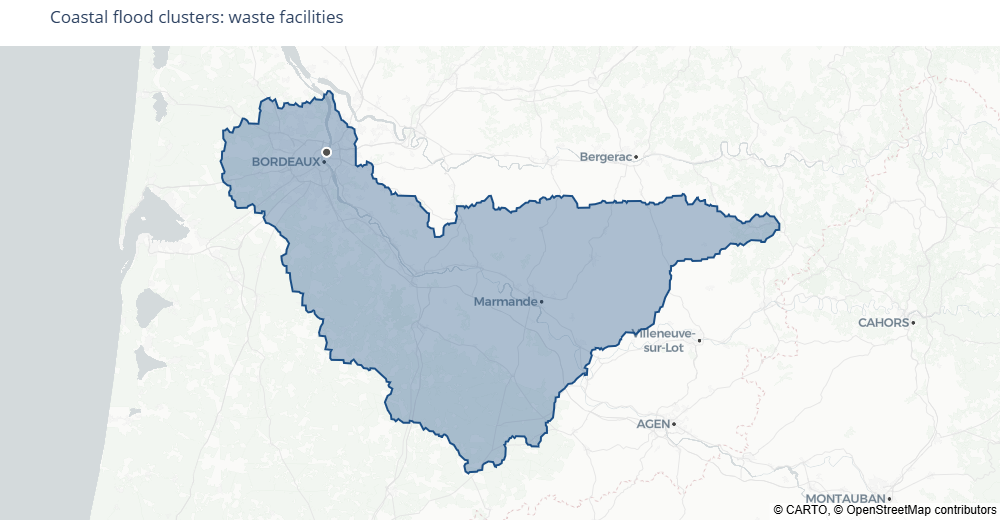

,cluster_id,assets,cluster_name,value,geometry
0,1,[WM3],Cluster 1,16000000.0,"MULTIPOLYGON(((12.34 45.44,12.339979866764718 ..."
1,2,[WM2],Cluster 2,40000000.0,"MULTIPOLYGON(((-0.54 44.86,-0.540020133235281 ..."
2,3,[WM1],Cluster 3,75000000.0,"MULTIPOLYGON(((5.88 51.85,5.879979866764719 51..."


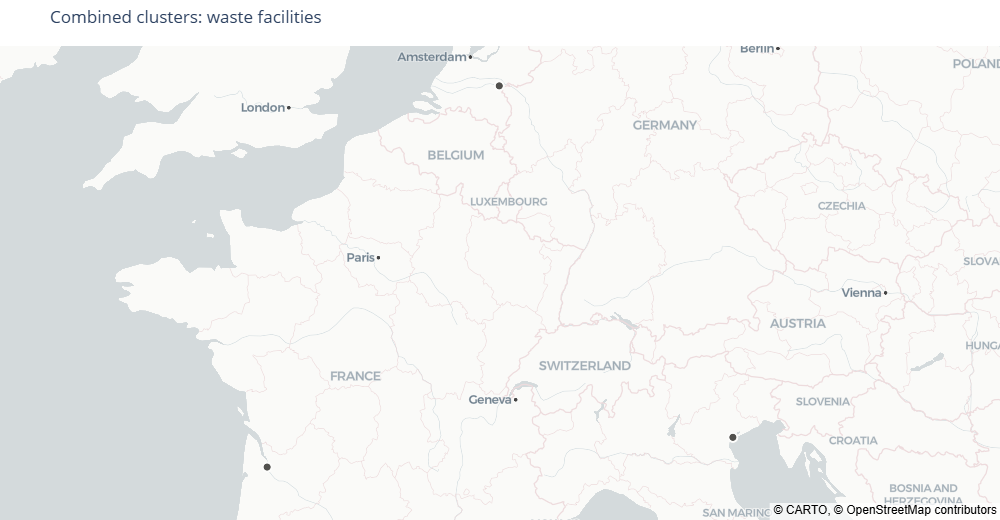

,cluster_id,assets,cluster_name,value,geometry
0,1,[WM2],Fire cluster 1,40000000.0,"MULTIPOLYGON(((-0.55 44.86033333333333,-0.55 4..."


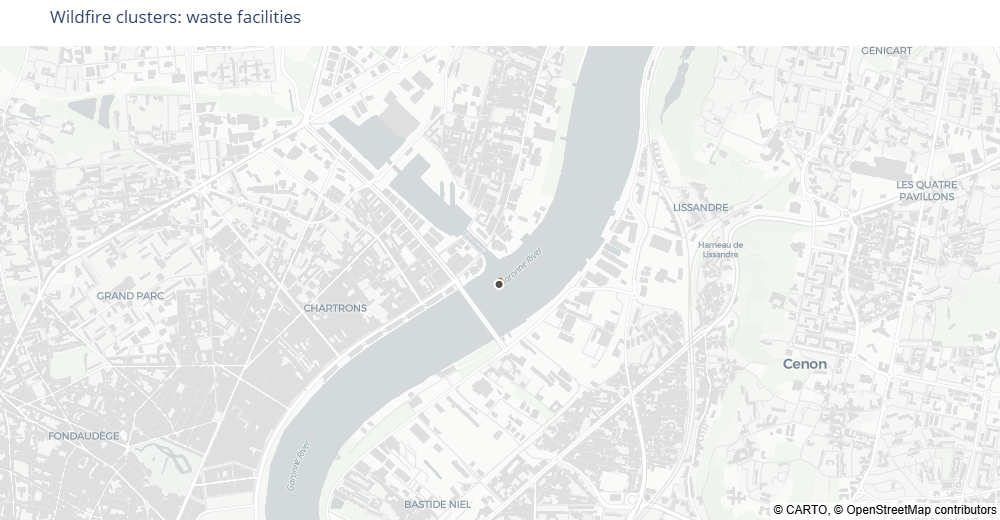

,cluster_id,assets,cluster_name,value,geometry
0,2090382960,[WM1],RiverineInundation cluster 2090382960,75000000.0,MULTIPOLYGON(((5.916666666666698 51.8208333333...
1,2090554170,[WM2],RiverineInundation cluster 2090554170,40000000.0,MULTIPOLYGON(((-0.541666666666639 44.900000000...


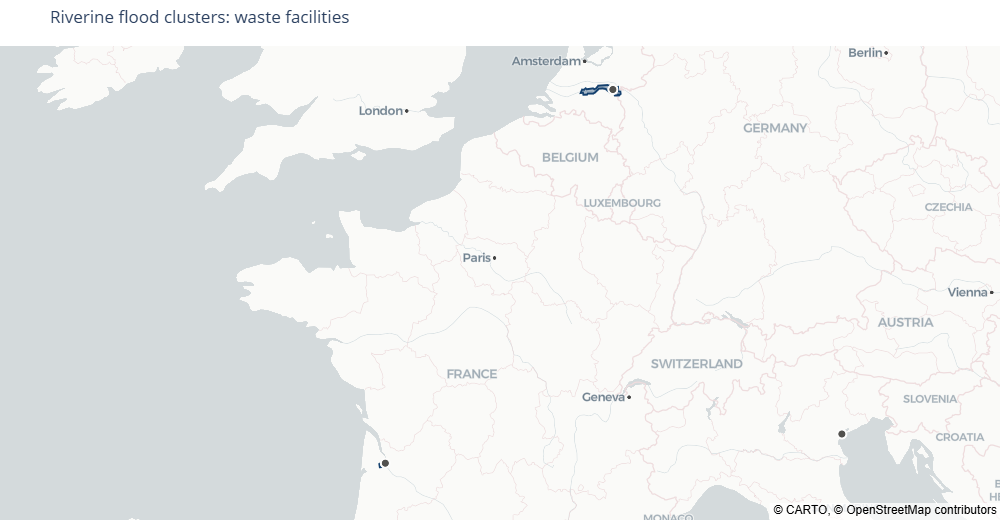

,cluster_id,assets,cluster_name,value,geometry
0,1,[WM3],Wind cluster 1,16000000.0,"MULTIPOLYGON(((12.34 45.44,12.339979866764718 ..."
1,2,[WM2],Wind cluster 2,40000000.0,"MULTIPOLYGON(((-0.54 44.86,-0.540020133235281 ..."
2,3,[WM1],Wind cluster 3,75000000.0,"MULTIPOLYGON(((5.88 51.85,5.879979866764719 51..."


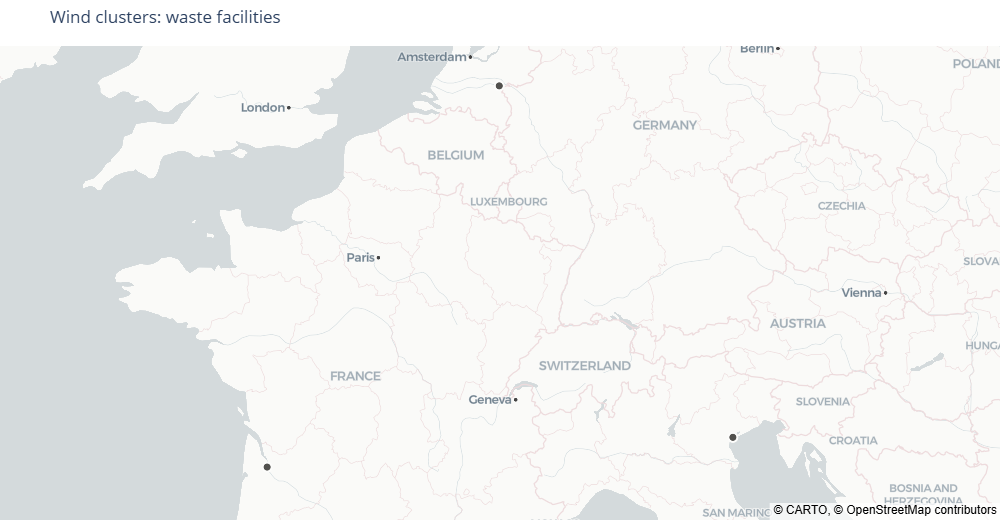

In [22]:
clusters_by_hazard = {hazard: show_clusters_for_hazard(hazard) for hazard in available_clustering_hazards_list}

## 9. Portfolio View

The previous sections looked at risk one asset or one hazard component at a time. The portfolio view asks a different question: after the assets have been registered, analysed, and clustered where relevant, what does the aggregated risk profile look like for the selected waste-facility portfolio?

For acute hazards, the portfolio-level endpoints use the results of the clustering pipeline in the aggregation. This means facilities assigned to the same hazard cluster can contribute to the same event-loss distribution rather than being treated as unrelated observations.


Use the portfolio-level endpoints when you want the total risk profile rather than the contribution of one asset or one spatial cluster. Following the parking and real-estate workflows, the example below requests the `Combined` portfolio view. To inspect one hazard only, set `portfolio_hazard` to a value such as `cluster_hazard`.


In [23]:
portfolio_hazard = "Combined"

portfolio_hazard_exceedance = requests.get(
    url=f"{API_BASE}/api/physical-asset-portfolios/{portfolio_code}/exceedance-curves?hazard={portfolio_hazard}",
    headers=HEADERS,
)
portfolio_metrics = requests.get(
    url=f"{API_BASE}/api/physical-asset-portfolios/{portfolio_code}/metrics?hazard={portfolio_hazard}",
    headers=HEADERS,
)
for response in [portfolio_hazard_exceedance, portfolio_metrics]:
    response.raise_for_status()

print("Portfolio hazard:", portfolio_hazard)


Portfolio hazard: Combined


The exceedance curve shows the annual probability that portfolio losses exceed a given amount. Compared with the asset-level expected-loss tables, this view is designed for portfolio risk questions such as concentration, tail loss, and aggregation across clustered assets.


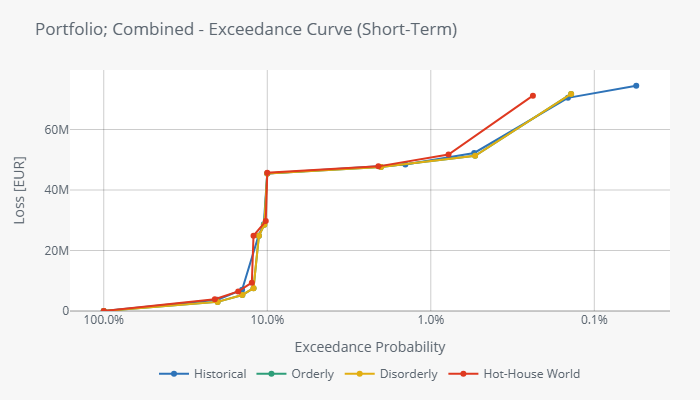

In [24]:
fig = fmp.plot_exceedance_curves(
    portfolio_hazard_exceedance,
    name=f"Portfolio; {HAZARD_LABEL.get(portfolio_hazard, portfolio_hazard)}",
    selected_term="short",
)
save_plot(fig, "p_portfolio_exceedance")
fig.show()


The same portfolio response also supports tail metrics. Value-at-Risk identifies the loss level at a selected confidence level, while Expected Shortfall reports the average loss conditional on being beyond that threshold.


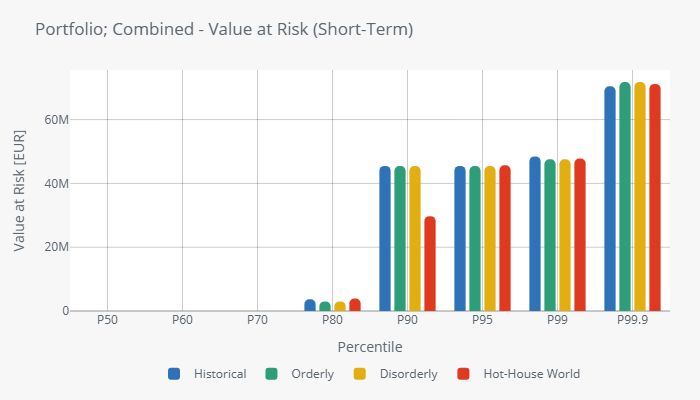

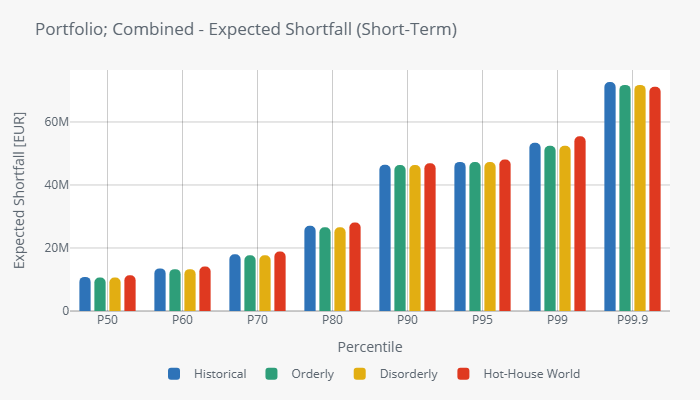

In [25]:
fig = fmp.plot_var(
    portfolio_metrics,
    name=f"Portfolio; {HAZARD_LABEL.get(portfolio_hazard, portfolio_hazard)}",
    selected_term="short",
)
save_plot(fig, "p_portfolio_var")
fig.show()

fig = fmp.plot_es(
    portfolio_metrics,
    name=f"Portfolio; {HAZARD_LABEL.get(portfolio_hazard, portfolio_hazard)}",
    selected_term="short",
)
save_plot(fig, "p_portfolio_es")
fig.show()


For management review, it is still useful to keep a compact component summary of the euro-denominated views calculated earlier in the notebook. This table replaces the former standalone financial roll-up: it preserves the useful portfolio totals without repeating the hazard-specific charts.


In [26]:
portfolio_summary = pd.DataFrame({
    "component": ["Flood: building", "Wind: building", "Heat: additional cooling"],
    "eur_per_year": [
        flood_df["expected_building_loss"].sum(),
        wind_df["expected_wind_loss"].sum(),
        heat_df["excess_cooling_cost_eur"].sum(),
    ],
})
save_table(portfolio_summary, "t_portfolio_summary")
print("Total expected annual climate cost in notebook views EUR",
      round(portfolio_summary["eur_per_year"].sum() / 1e6, 2), "M/yr")
display(portfolio_summary)


Total expected annual climate cost in notebook views EUR 5.92 M/yr


,component,eur_per_year
0,Flood: building,5906900.000
1,Wind: building,6542.400
2,Heat: additional cooling,2133.885


## 10. Provenance by Asset

The previous sections produced asset-level hazard views, clustering outputs, and portfolio-level charts and metrics. This section brings the results back down to the individual facility level, so the user can see exactly what sits behind those summaries.

The provenance table is designed as an audit and review aid. Each row represents one waste facility and combines the main inputs and outputs used in the priced hazard views:

- the asset identity and value base;
- the selected flood driver, riverine or coastal;
- the flood damage ratio returned by the API for the configured headline flood case;
- the wind damage ratio returned by the API for the configured wind case;
- the expected flood and wind losses;
- the estimated additional cooling cost from the chronic-heat calculation;
- the headline risk score from the screening table.

This table is useful when a reviewer asks why a particular facility is driving the portfolio result. The reviewer can trace the result back to the facility's exposure assumptions, scenario, year, model output, and client-side calculation.


In [27]:
prov = flood_df[["id", "name", "building_value", "driver", "struct_ratio", "expected_building_loss"]].copy()
prov = prov.rename(columns={"struct_ratio": "flood_damage_ratio", "expected_building_loss": "expected_flood_building_loss"})
prov = prov.merge(wind_df[["id", "insured_value", "wind_ratio", "expected_wind_loss"]], on="id", how="left")
prov = prov.merge(heat_df[["id", "floor_area_m2", "excess_cooling_cost_eur"]], on="id", how="left")
prov = prov.merge(scores[["id", "worst_score"]], on="id", how="left")
save_table(prov, "t_provenance")
display(prov)

,id,name,building_value,driver,flood_damage_ratio,expected_flood_building_loss,insured_value,wind_ratio,expected_wind_loss,floor_area_m2,excess_cooling_cost_eur,worst_score
0,WM1,Afval Energie Centrale Nijmegen,75000000,Riverine,0.06494,4870500.0,75000000,0.000000,0.0,15000,533.8386,3
1,WM2,Centre de tri Bordeaux,40000000,Coastal,0.02591,1036400.0,40000000,0.000000,0.0,8000,1600.0464,2
2,WM3,Stazione di trasferimento Venezia,16000000,Riverine,0.00000,0.0,16000000,0.000409,6542.4,4000,0.0000,2


## 11. Traceability and Methodology

This section explains which method sits behind each hazard in this notebook. This is important because the hazard score table uses a consistent 0-to-3 format, but the underlying calculation is not identical for every hazard.

The traceability table distinguishes between two broad types of score:

- **IMPACT scores**, where the API applies a vulnerability or damage model to translate hazard intensity into an asset impact signal;
- **HAZARD scores**, where the API reads the hazard indicator directly against fixed thresholds because no asset-specific damage curve is used in this workflow.

The table also identifies which parts are returned by the Alpha-Klima API and which parts are assembled in the notebook. In this run, flood and wind damage ratios come from the platform response, while the chronic-heat euro cost is a client-side calculation based on API cooling-degree-day data and the assumptions configured earlier. The asset-level flood VaR and Expected Shortfall are calculated client-side from the `impact_distribution` returned by the platform; the Portfolio View uses platform portfolio endpoints after the clustering workflow.

The table below is assembled in the notebook from what is published on the platform documentation site, so it is a curated view of documented material rather than anything derived here. Everything in it can be read there in full, which is also the place to look for the hazard models, the vulnerability curves and the scoring methodology behind each row.

Use this section when validating the workflow internally, explaining results to non-technical stakeholders, or deciding which assumptions a client team may want to replace with its own data. Full methodology documentation is available on the Alpha-Klima documentation site: https://platform.alpha-klima.com/docs/index.html.


In [28]:
TRACE = [
 ("RiverineInundation", "flood_depth", "occ 1151 -> Hazus IND", "WRI flood depth + Hazus IND1 combined curve", "IMPACT", "platform", "Industrial occupancy reaches the combined Hazus industrial curve", "WRI Aqueduct; FEMA Hazus"),
 ("CoastalInundation", "flood_depth", "occ 1151 -> Hazus IND", "WRI coastal flood depth + Hazus IND1 combined curve", "IMPACT", "platform", "Same combined industrial curve as riverine", "WRI Aqueduct; FEMA Hazus"),
 ("Flood damage components", "flood_depth", "occ 1151 -> Hazus IND (combined)", "Structure, components and inventory combined in one curve", "IMPACT", "platform", "One combined damage ratio is returned; selecting an individual damage component is on the way", "FEMA Hazus"),
 ("Wind", "wind_speed/3s", "generic RealEstate (occ -1, type=Generic, country)", "WISC 3s gust + generic building wind curve (aggregate)", "IMPACT", "platform", "Industrial occupancy has no wind curve; the generic building curve gives one aggregate ratio applied to total insured value. No structure/contents split: the Hazus industrial wind curves are keyed to max_speed, which is ~0 in Europe", "WISC; JRC/Huizinga"),
 ("Flood tail (VaR/ES)", "flood_depth", "structure impact_distribution", "Discrete quantile + tail mean over the impact PMF; interpolated within bins when CONFIG['var_es_interpolate']", "IMPACT", "client-side", "Mirrors the Alpha-Klima financial module; temporary until the platform exposes tail metrics through the API", "Alpha-Klima financial module"),
 ("ChronicHeat", "cooling_degree_days/index", "generic RealEstate", "Score: platform cooling model. Cost: excess CDD (scenario - historical 2005) x UA(floor area x per-m2 coeff) / COP", "IMPACT", "platform score / client-side cost", "Cost is the excess over baseline scaled by building size; provisional model, with an enhanced methodology being onboarded into the platform", "ECB SPS No.48; cooling model"),
 ("Portfolio clustering and aggregation", "portfolio risks, clusters, exceedance curves, and metrics", "physical-asset portfolio pipeline", "Clustered portfolio financial module", "IMPACT", "platform", "Groups assets by returned hazard clusters and exposes Combined portfolio risk metrics", "Alpha-Klima financial module"),
 ("Fire", "fire_probability", "generic RealEstate", "Generic wildfire damage curve", "IMPACT", "platform", "Generic curve; no industrial-specific fire curve", "Alpha-Klima wildfire"),
 ("Landslide", "landslide_susceptability", "occ 1151 / generic", "Landslide susceptibility damage curve", "IMPACT", "platform", "Susceptibility-based damage", "JRC"),
 ("WaterRisk", "water_stress", "generic RealEstate", "None (score from intensity)", "HAZARD", "platform", "Score-only: water-stress ratio thresholds", "WRI Aqueduct 4.0"),
 ("Subsidence", "subsidence_susceptability", "generic RealEstate", "None (score from intensity)", "HAZARD", "platform", "Score-only: susceptibility index thresholds", "JRC"),
 ("Drought", "cdd", "generic RealEstate", "None (score from intensity)", "HAZARD", "platform", "Score-only: consecutive dry days thresholds", "Copernicus"),
 ("Hail", "hail_probability", "generic RealEstate", "None (score from intensity)", "HAZARD", "platform", "Score-only: annual large-hail probability", "TU Delft RAIN"),
 ("Snow", "blizzard_probability", "generic RealEstate", "None (score from intensity)", "HAZARD", "platform", "Score-only: annual blizzard probability", "TU Delft RAIN"),
 ("FreezingRain", "freezing_rain_probability", "generic RealEstate", "None (score from intensity)", "HAZARD", "platform", "Score-only: freezing-rain probability", "TU Delft RAIN"),
]
trace_df = pd.DataFrame(TRACE, columns=["hazard", "indicator_id", "routing", "model / curve resolved",
                                        "score source", "computed by", "why this model", "reference"])
save_table(trace_df, "t_traceability")
display(trace_df)


,hazard,indicator_id,routing,model / curve resolved,score source,computed by,why this model,reference
0,RiverineInundation,flood_depth,occ 1151 -> Hazus IND,WRI flood depth + Hazus IND1 combined curve,IMPACT,platform,Industrial occupancy reaches the combined Hazu...,WRI Aqueduct; FEMA Hazus
1,CoastalInundation,flood_depth,occ 1151 -> Hazus IND,WRI coastal flood depth + Hazus IND1 combined ...,IMPACT,platform,Same combined industrial curve as riverine,WRI Aqueduct; FEMA Hazus
2,Flood damage components,flood_depth,occ 1151 -> Hazus IND (combined),"Structure, components and inventory combined i...",IMPACT,platform,One combined damage ratio is returned; selecti...,FEMA Hazus
3,Wind,wind_speed/3s,"generic RealEstate (occ -1, type=Generic, coun...",WISC 3s gust + generic building wind curve (ag...,IMPACT,platform,Industrial occupancy has no wind curve; the ge...,WISC; JRC/Huizinga
4,Flood tail (VaR/ES),flood_depth,structure impact_distribution,Discrete quantile + tail mean over the impact ...,IMPACT,client-side,Mirrors the Alpha-Klima financial module; temp...,Alpha-Klima financial module
5,ChronicHeat,cooling_degree_days/index,generic RealEstate,Score: platform cooling model. Cost: excess CD...,IMPACT,platform score / client-side cost,Cost is the excess over baseline scaled by bui...,ECB SPS No.48; cooling model
6,Portfolio clustering and aggregation,"portfolio risks, clusters, exceedance curves, ...",physical-asset portfolio pipeline,Clustered portfolio financial module,IMPACT,platform,Groups assets by returned hazard clusters and ...,Alpha-Klima financial module
7,Fire,fire_probability,generic RealEstate,Generic wildfire damage curve,IMPACT,platform,Generic curve; no industrial-specific fire curve,Alpha-Klima wildfire
8,Landslide,landslide_susceptability,occ 1151 / generic,Landslide susceptibility damage curve,IMPACT,platform,Susceptibility-based damage,JRC
9,WaterRisk,water_stress,generic RealEstate,None (score from intensity),HAZARD,platform,Score-only: water-stress ratio thresholds,WRI Aqueduct 4.0


### Sources and assumptions

- Flood uses the Hazus industrial IND1 curve reached through the industrial occupancy routing in the JSON, which the platform serves as a single combined curve covering structure, components and inventory damage. In the example data this is OED occupancy 1151. Riverine and coastal flood are both requested; each site takes the larger expected damage ratio for the headline view.
- The combined curve returns one damage ratio per asset, applied to `value`, which is `structure_value` plus `contents_value`. Contents here means the fixed process equipment and machinery. Selecting an individual damage component is a planned platform feature.
- Wind uses the WISC extreme 3-second gust field, for which the platform resolves a generic building wind curve. That gives one aggregate damage ratio per site, applied to `value`, the same structure plus contents base used for flood. There is no structure/contents split for European wind in this workflow.
- The notebook needs no local vulnerability data. Flood and wind damage functions, including their loss distributions where available, are resolved by the platform from the assets it is sent.
- Chronic heat is reported as the additional cooling-energy cost versus the historical baseline, scaled by facility floor area and priced at the configured electricity tariff. The facilities in this example are in the Netherlands, France and Italy, but a single reference tariff is applied to all of them so the cost comparison between sites reflects cooling demand rather than national tariff differences. Tariff source: Eurostat `nrg_pc_205` (Spain, non-household band, including taxes and levies), recorded in `CONFIG["tariff_source"]`. Using per-country tariffs would change the euro figures. Costs are in constant real terms: the current tariff is applied to future cooling demand with no energy-price inflation, so figures across horizons are directly comparable.
- The chronic-heat euro calculation is client-side and uses `auxiliary_functions/cooling_model.py`. It is a provisional model, and an enhanced methodology for it is being onboarded into the platform. The 0-to-3 heat score comes from the platform cooling model.
- Value-at-Risk and Expected Shortfall are computed client-side by `auxiliary_functions/tail_metrics.py` from the per-asset `impact_distribution` the API already returns, and rendered with the shared `financial_metrics_plots` helpers. The math mirrors Alpha-Klima's financial module, so the figures should not move when the platform exposes these metrics through the API. That module is temporary and should be deleted once those endpoints land.
- The risk-score table uses the industrial routing where it resolves a hazard and a generic real-estate routing otherwise. Score-only hazards carry no damage curve.
- Clustering is run through the physical-asset portfolio pipeline. The notebook displays whichever clustered hazards the API returns, with the priced acute hazards shown first when available. Portfolio exceedance curves, VaR, and Expected Shortfall are requested from the portfolio endpoints after clustering.
- Scenario labels are transition narratives rather than pathway identifiers. When a requested narrative has no data for a given hazard, the platform resolves it to the closest available pathway, so two narratives can be served from the same underlying series and their curves overlap.
- Full model documentation, including hazard models, vulnerability curves, and the scoring methodology, is on the Alpha-Klima docs site: https://platform.alpha-klima.com/docs/index.html
- Asset values and waste-facility attributes are illustrative. Results are for screening, not regulatory submission.
